# BigQuery のデータを用いたビジネス分析 AI エージェント

このノートブックでは、BigQuery に保存された e-コマースサイトのビジネスデータを分析する AI エージェントを実装します。

特に、保存データの構造や利用方法をまとめた「ナレッジベース」を用いて、データ分析におけるハルシネーションを回避する方法を説明します。このナレッジベースは、一般に、データベースの「セマンティックレイヤー」に相当します。


## 事前準備

**[BAA-01]**

ADK と Gemini API の利用に必要なパッケージをインストールします。

ADK は開発の速度が速く、後方互換性のない機能変更が行われることがあります。ここでは、安全のために動作確認ができたバーションを指定してインストールしています。

**最後に `RESTART SESSION` ボタンが表示された場合は、これをクリックしてセッションを再起動してください。**

**注意**: `ERROR: pip's dependency resolver does not currently take into account...` のようなエラーメッセージが表示される場合がありますが、これは無視して構いません。

In [ ]:
%pip install --upgrade --user \
    google-adk==2.8.0 \
    google-cloud-aiplatform==2.0.1 \
    google-cloud-dataplex==2.20.0 \
    google-genai==2.20.0 \
    vl-convert-python==1.9.0.post1 \
    pillow==12.3.0

**[BAA-02]**

インストールされたパッケージのバージョンを確認します。

In [1]:
!pip list | grep -E "(google-adk|google-genai|google-cloud-aiplatform|google-cloud-dataplex|vl-convert-python|pillow)"

google-adk                            2.8.0
google-cloud-aiplatform               2.0.1
google-cloud-dataplex                 2.20.0
google-genai                          2.20.0
pillow                                12.3.0
vl-convert-python                     1.9.0.post1


下記の内容が出力されたことを確認してください。

```
google-adk                               2.8.0
google-cloud-aiplatform                  2.0.1
google-cloud-dataplex                    2.20.0
google-genai                             2.20.0
pillow                                   12.3.0
vl-convert-python                        1.9.0.post1
```

## ユーザー認証

**[BAA-03]**

変数 `PROJECT_ID` に事前に準備したプロジェクトのプロジェクト ID を指定してください。

**注意**: プロジェクトを作成したユーザーアカウントと Colab を使用中のユーザーアカウントが一致している必要があります。


In [ ]:
###
PROJECT_ID = 'Project ID を入力'
###

if (not PROJECT_ID) or PROJECT_ID == 'Project ID を入力':
    print('Gemini API を使用する Google Cloud Project の Project ID を入力してください。')
else:
    print(f'変数 PROJECT_ID を設定しました。')
    print(f'PROJECT_ID = {PROJECT_ID}')

**[BAA-04]**

Google Cloud のプロジェクトを使用するためのユーザー認証を行います。

ポップアップ画面の指示に従って、認証処理を行ってください。

許可する操作を選択するチェックボックスが表示された場合は、すべてにチェックを入れてください。

In [3]:
from google.colab import auth
auth.authenticate_user(project_id=PROJECT_ID)

## 初期設定

**[BAA-05]**

この後の作業に必要なモジュールをインポートして、LlmAgent オブジェクトが参照する環境変数を設定します。あわせて、アーティファクトを保存するクラウドストレージのバケットを作成します。

In [4]:
import base64, copy, json, io, os, re, urllib, uuid
import vl_convert as vlc
from PIL import Image
from IPython.display import Markdown, display
import agentplatform
from agentplatform.frameworks import AdkApp
from google import auth
from google.genai.types import (
    Content, HttpOptions, HttpRetryOptions, ImageConfig,
    Part, SafetySetting, ThinkingConfig, ThinkingLevel,
)
from google.adk.agents.llm_agent import LlmAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.models.google_llm import Gemini
from google.adk.integrations.bigquery import BigQueryCredentialsConfig, BigQueryToolset
from google.adk.integrations.bigquery.config import BigQueryToolConfig, WriteMode
from google.adk.planners import BuiltInPlanner
from google.adk.plugins.save_files_as_artifacts_plugin import SaveFilesAsArtifactsPlugin
from google.adk.tools import ToolContext
from google.adk.tools.agent_tool import AgentTool

agentplatform.init(project=PROJECT_ID, location='us-central1')
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = 'global'
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

BUCKET_NAME = f'{PROJECT_ID}_artifacts'
!gcloud storage ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gcloud storage buckets create -b -l us-central1 gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_artifacts/


**[BAA-06]**

AdkApp オブジェクトとの会話を行う簡易的なアプリケーションのクラス ChatClient を定義します。

In [5]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result)

**[BAA-07]**

「日本語テキスト出力時のマークダウン表示崩れの防止ルール」と Gemini API のモデル選択をテンプレートとして用意しておきます。

In [6]:
markdown_rule = r'''
# 日本語テキスト出力時のマークダウン表示崩れの防止ルール
マークダウンの修飾記号（太字 `**` や斜体 `*` など）と、日本語の特殊記号や全角文字が隣り合うことで生じる表示崩れを防ぐため、以下のルールを厳守してください。

## 1. 記号と太字の間にスペースを入れる基本ルール
太字記号（`**`）の直前・直後に、鉤括弧や丸括弧、その他の記号が来る場合は、必ず半角スペースを1つ挟んでください。

- **全角鉤括弧（「」）：**
  - 【NG例】`**「重要」**なポイント`
  - 【OK例】`**「重要」** なポイント`
- **全角・半角の丸括弧（（） / ()）：**
  - 【NG例】`**（注意）**事項です`
  - 【OK例】`**（注意）** 事項です`
- **パーセント（% / ％）や数値・単位：**
  - 【NG例】`達成率は**100%**です`
  - 【OK例】`達成率は **100%** です`

## 2. 記号自体のエスケープと厳禁な組み合わせ
- マークダウンの特殊文字として誤認されやすい半角記号（`*`, `_`, `~`, `\` など）をそのまま表示する場合は、隣接するアスタリスク等との間にスペースを設けてください。
- アンダースコア（`_`）は単語の途中の日本語や全角文字と混ざると強力なイタリック・太字パーサに拾われやすいため、強調用以外では原則として直接隣接させないでください。

## 3. 通貨記号 `$` のエスケープ
- 通貨記号 `$` は数式の開始と誤認されないようにエスケープして出力してください。
  - 【NG例】`$100`
  - 【OK例】`\$100`
'''

flash_lite_model = Gemini(
    model='gemini-3.1-flash-lite',
    retry_options=HttpRetryOptions(),
)

flash_model = Gemini(
    model='gemini-3.8-flash',
    retry_options=HttpRetryOptions(),
)

planner = BuiltInPlanner(
    thinking_config=ThinkingConfig(
        thinking_level=ThinkingLevel.LOW,
        include_thoughts=False,
    ),
)

**[BAA-08]**

`bigquery_toolset` を用意します。これは、BigQuery のデータセットを検索するための次のツール群を提供します。

- list_dataset_ids: プロジェクト内に存在するデータセット ID を取得する
- get_dataset_info: データセットに関するメタデータを取得する
- list_table_ids: データセット内に存在するテーブル ID を取得する
- get_table_info: テーブルに関するメタデータを取得する
- execute_sql: SQL を実行し、結果を取得する
- ask_data_insights: 自然言語を使用して、テーブル内のデータに関する質問に回答する

In [7]:
tool_config = BigQueryToolConfig(write_mode=WriteMode.BLOCKED)

application_default_credentials, _ = auth.default()
credentials_config = BigQueryCredentialsConfig(
    credentials=application_default_credentials
)

bigquery_toolset = BigQueryToolset(
    credentials_config=credentials_config,
    bigquery_tool_config=tool_config,
)

/root/.local/lib/python3.13/site-packages/google/adk/features/_feature_decorator.py:71: UserWarning: [EXPERIMENTAL] feature FeatureName.GOOGLE_CREDENTIALS_CONFIG is enabled.
  check_feature_enabled()


**[BAA-09]**

`bigquery_toolset` を用いて、"theLook eCommerce" データセットのテーブルを確認するAIエージェントを用意します。

In [8]:
instruction = f'''
ユーザーの指示に従って、データセットのテーブル情報を返答します。
- [テーブル名, 説明, 主要なデータ]を列に持つ表形式で出力します。
- 説明は、「顧客マスタ」「注文情報」など一般的なビジネスデータベースの用語を用いること。
- プログラムで生成された仮想データの場合、現実のデータという想定で記述すること。

# データ取得方法
bigquery_toolset を用いて以下の情報を参照してください。
- 対象データセット: `project id: bigquery-public-data` / `dataset: thelook_ecommerce`
- 実行環境: BigQuery Job は `project id: {PROJECT_ID}` で実行すること。
'''

dataset_agent = LlmAgent(
    name='dataset_agent',
    model='gemini-3.1-flash-lite',
    description='データセットの情報を調べるAIエージェント',
    instruction=instruction,
    tools=[bigquery_toolset],
)

dataset_agent_app = AdkApp(
    agent=dataset_agent,
    app_name='dataset_agent_app',
)

**[BAA-10]**

用意したAIエージェントを用いて、テーブルの情報を取得します。

In [23]:
chat_client = ChatClient(dataset_agent_app)

query = '''
データセット thelook_ecommerce に含まれるテーブルを教えてください。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

データセット `thelook_ecommerce` に含まれるテーブルの一覧です。

| テーブル名 | 説明 | 主要なデータ |
| :--- | :--- | :--- |
| `distribution_centers` | 配送センター管理 | 配送センターの名称、所在地 |
| `events` | Webイベントログ | ユーザーの行動履歴、セッション情報、アクセス端末 |
| `inventory_items` | 在庫管理マスタ | 商品の在庫状況、入荷・出荷情報、原価、販売価格 |
| `order_items` | 注文明細情報 | 注文に含まれる個別の商品情報、販売価格、配送ステータス |
| `orders` | 注文情報 | 注文全体の状態、ユーザー情報、注文日時、配送ステータス |
| `products` | 商品マスタ | 商品名、カテゴリー、ブランド、価格 |
| `users` | 顧客マスタ | 顧客の個人情報、住所、登録情報、属性 |

## グラフ画像を作成するツール関数

**[BAA-11]**

Vega-Lite の JSON テキストを受け取って、グラフ画像を作成・保存する関数を定義します。

In [9]:
async def save_vega_chart_artifact(
    vl_spec_json: str, tool_context: ToolContext,
) -> str:
    """
    Vega-Lite の JSON 仕様を受け取り、PNG 画像としてアーティファクトに保存します。

    Args:
        vl_spec_json (str): Vega-Lite の JSON 仕様文字列

    Returns:
        str: アーティファクトのファイルネーム（もしくはエラーメッセージ）
    """

    try:
        font_dir = './fonts'
        font_path = os.path.join(font_dir, 'NotoSansCJKjp-Regular.otf')
        font_url = 'https://github.com/kongou-ae/font/raw/refs/heads/master/NotoSansCJKjp-Regular.otf'
        os.makedirs(font_dir, exist_ok=True)
        if not os.path.exists(font_path):
            print('## Downloading NotoSansCJKjp-Regular.otf...', flush=True)
            urllib.request.urlretrieve(font_url, font_path)
        vlc.register_font_directory(font_dir)
    except Exception as e:
        message = f'フォントの設定に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

    try:
        spec = json.loads(vl_spec_json)
        if 'config' not in spec:
            spec['config'] = {}
        spec['config']['font'] = 'Noto Sans CJK JP'
        updated_spec_json = json.dumps(spec)
        png_data = vlc.vegalite_to_png(vl_spec=updated_spec_json, ppi=90)
        artifact = Part.from_bytes(data=png_data, mime_type='image/png')
        filename = f'{uuid.uuid4()}.png'
        await tool_context.save_artifact(filename=filename, artifact=artifact)
        return filename
    except Exception as e:
        message = f'画像の生成または保存に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

**[BAA-12]**

ツール関数 `save_vega_chart_artifact` を利用して、グラフ画像を作成する LlmAgent オブジェクト `chart_agent` を定義します。

`AgentTool(chart_agent)` でツール関数に変換すると、グラフ画像を作成するツール関数として利用できます。

In [10]:
instruction='''
あなたはデータ可視化の専門家です。ユーザーからの依頼に応じて、次の手順でグラフ画像を作成します。
1. 提供されたデータと要件に基づき、適切な Vega-Lite の JSON 仕様を生成する。タイトル、ラベル、凡例は日本語を使用する。
2. 生成した JSON 仕様を save_vega_chart_artifact で PNG 画像として保存する。
3. 作成したグラフのタイトルと保存したファイル名を次のフォーマットで出力する。
```
- title: <グラフのタイトル>
- filename: <ファイル名>
```
'''

chart_agent = LlmAgent(
    name='chart_agent',
    model=flash_lite_model,
    description='与えられたデータからグラフを作成する AI エージェント',
    instruction=instruction,
    tools=[save_vega_chart_artifact],
)

## ファイル名と画像ファイルデータを相互変換するコールバック関数

**[BAA-13]**

マークダウンテキスト内の `![<画像の説明>](<ファイル名>)`という部分を対応するアーティファクトを用いて、`![<画像の説明#ファイル名>](<base64 文字列>)` に置換する関数を定義します。

In [11]:
async def replace_filename_with_base64(
    markdown_text, quality=80, max_width=300,
    callback_context=None,
):
    pattern = r'!\[(.*?)\]\((.*?)\)'

    # find filenames in the markdown text.
    matches = list(re.finditer(pattern, markdown_text, flags=re.MULTILINE))
    if not matches:
        return markdown_text
    unique_filenames = {match.group(2) for match in matches}

    image_map = {}
    for filename in unique_filenames:
        print(f'## Converting `{filename}` into base64 string.', flush=True)
        image_artifact = await callback_context.load_artifact(filename=filename)
        image_bytes = image_artifact.inline_data.data

        # Resize and convert to jpeg image.
        with Image.open(io.BytesIO(image_bytes)) as img:
            if img.mode in ('RGBA', 'P'):
                img = img.convert('RGB')
            if max_width and img.width > max_width:
                ratio = max_width / img.width
                new_height = int(img.height * ratio)
                img = img.resize((max_width, new_height), Image.Resampling.LANCZOS)

            output_buffer = io.BytesIO()
            img.save(output_buffer, format='JPEG', quality=quality, optimize=True)
            jpeg_data = output_buffer.getvalue()

        # Create filename to base64 string map.
        b64_encoded = base64.b64encode(jpeg_data).decode('utf-8')
        image_map[filename] = f'data:image/jpeg;base64,{b64_encoded}'

    def replacer(match):
        alt_text, filename = match.group(1), match.group(2)
        return f'![{alt_text}#{filename}]({image_map[filename]})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)

**[BAA-14]**

関数 `replace_filename_with_base64` で大規模言語モデルの応答メッセージに含まれるファイル名を対応するアーティファクトの base64 文字列に置き換えて、インライン画像を用意するコールバック関数を定義します。

In [12]:
async def callback_load_images(
    callback_context, llm_response,
):
    if not (llm_response.content and llm_response.content.parts):
        return None

    for part in llm_response.content.parts:
        if not part.text:
            continue
        part.text = await replace_filename_with_base64(
            part.text, quality=80, max_width=800,
            callback_context=callback_context,
        )

    return None

**[BAA-15]**

マークダウンテキスト内の `![<画像の説明#ファイル名>](<base64 文字列>)` という部分を `![<画像の説明>](<ファイル名>)` に置換する関数を定義します。

In [13]:
def replace_base64_with_filename(markdown_text):
    pattern = r'!\[(.*?)\]\(data:image/(?:jpeg|png|gif|bmp|webp);base64,[A-Za-z0-9+/=]+\)'

    def replacer(match):
        original_alt_text = match.group(1)
        if '#' in original_alt_text:
            parts = original_alt_text.split('#')
            filename = parts[-1]
            clean_alt_text = '#'.join(parts[:-1])
        else:
            return match.group(0)

        print(f'## Replacing base64 string with `{filename}`', flush=True)
        return f'![{clean_alt_text}]({filename})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)

**[BAA-16]**

関数 `replace_base64_with_filename` で大規模言語モデルへの入力メッセージに含まれるインライン画像をファイル名に置き換えるコールバック関数を定義します。

In [14]:
async def callback_remove_base64(
    callback_context, llm_request,
):
    if not llm_request.contents:
        return None

    for content in llm_request.contents:
        if not content.parts:
            continue
        for part in content.parts:
            if not part.text:
                continue
            part.text = replace_base64_with_filename(part.text)

    return None

## ナレッジベースの作成

**[BAA-17]**

BigQuery のテーブルセットを分析して、ナレッジベースのベースラインを作成する AI エージェントを定義します。

In [18]:
instruction = f'''
あなたは、後続のAIアナリストに向けた「データ分析用ナレッジベース（KB）」を作成する高度なコンテキスト・ジェネレーターです。
後続のAIが自由に集計・絞り込みできるよう、事前集計されていない「全期間・明細レベル（ミクロデータ）」のベースSQLを定義してください。

# 1. データの抽出とSQL作成の基本原則
- 明細レベルの維持: `GROUP BY` 等による事前集計はせず、トランザクションの明細を維持すること。
- リッチなデータ結合: トランザクション（注文など）を中心に、マスタデータ（ユーザー、商品など）を豊富に `JOIN` しておくこと。
- 【重要】サンプリングの扱い: データの特徴やサンプルを抽出・確認する際は、負荷軽減のため `RAND()` や `TABLESAMPLE` を用いて抽出を行ってください。ただし、**最終的にKBへ出力する「ベースSQL」には、サンプリング（`LIMIT` や `TABLESAMPLE` など）を一切含めない**でください。

# 2. 生成するKBのビジネスセクション
以下の4つの視点でベースSQLを作成してください。
1. 売上・商品分析（orders, order_items, products等）
2. 顧客プロファイリング（users, 購買履歴等）
3. 物流・オペレーション（orders, 配送ステータス等）
4. ユーザー行動（events, セッション等）

# 3. データ取得環境
- ツール: `bigquery_toolset` を使用
- 対象データセット: `project id: bigquery-public-data` / `dataset: thelook_ecommerce`
- 実行環境: Project ID `{PROJECT_ID}`

# 4. 出力フォーマット
以下のMarkdownフォーマットに厳密に従って出力してください。挨拶などは不要です。

```markdown
# TheLook eCommerce データナレッジベース

## セクション：[ビジネス視点]
### データのポテンシャル
※ このデータを使ってどのような分析（例：「カテゴリ別の売上推移」など）が可能か。

### 分析用ベース SQL
※ サンプリング句（`LIMIT`, `TABLESAMPLE`等）を含まない、全期間・全件対象の純粋なSELECT文。
※ 後続AIがこれをCTE（WITH句）として使い回せる構成にすること。

### データ件数（サンプリング前・全件）

### データのサンプル（20件）
※ プレビュー用に抽出したサンプルデータを表形式で提示。

### 統計的特徴・異常値・分析のヒント
※ サンプルデータやクエリ実行結果から読み取れる、分析の切り口となる特徴。
```

{markdown_rule}
'''

kb_generator_agent = LlmAgent(
    name='kb_generator_agent',
    model=flash_model,
    description='データ分析のナレッジベースを作成する AI エージェント',
    instruction=instruction,
    tools=[bigquery_toolset],
)

kb_generator_app = AdkApp(
    agent=kb_generator_agent,
    app_name='kb_generator_app',
)

**[BAA-18]**

ナレッジベースのベースラインを作成して、ファイル `knowledge_base.md` に保存します。

実際の運用では、ここで用意されたファイルをデータアナリストがチェックして、内容を修正・拡充したものを使用します。

In [19]:
chat_client = ChatClient(kb_generator_app)

query = '''
利用可能なデータを確認した上でナレッジベースを作成。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

with open('knowledge_base.md', 'w') as f:
    f.write(response)

/root/.local/lib/python3.13/site-packages/agentplatform/frameworks/adk.py:1146: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  self._tmpl_attrs["credential_service"] = InMemoryCredentialService()
/root/.local/lib/python3.13/site-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()


# TheLook eCommerce データナレッジベース

## セクション：売上・商品分析
### データのポテンシャル
注文明細（order_items）を中心に注文ヘッダ（orders）、商品マスタ（products）、ユーザー属性（users）を結合した、トランザクションの粒度を完全に保持したデータセットです。このデータをベースにすることで、以下のような多角的な分析が可能です。

- **商品・ブランド別の売上および粗利分析：** カテゴリ別・ブランド別の売上高、粗利益額（sale_price - cost）、粗利率の算出
- **値引き影響の測定：** 定価（retail_price）と実売価格（sale_price）の差異から、ディスカウント率と購買転換の相関分析
- **時系列トレンド・コホート売上分析：** 注文日時（order_created_at）に基づく月次・週次の売上成長率や、顧客属性（年齢層・性別・地域）別の売上推移
- **注文ステータス別インパクト評価：** 完了（Complete）、出荷済み（Shipped）、キャンセル（Cancelled）、返品（Returned）ごとの売上損失・返品リスク分析

### 分析用ベース SQL
```sql
SELECT
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.product_id,
  oi.inventory_item_id,
  oi.status AS order_item_status,
  o.status AS order_status,
  o.created_at AS order_created_at,
  oi.shipped_at,
  oi.delivered_at,
  oi.returned_at,
  ROUND(CAST(oi.sale_price AS NUMERIC), 2) AS sale_price,
  ROUND(CAST(p.cost AS NUMERIC), 2) AS product_cost,
  ROUND(CAST(p.retail_price AS NUMERIC), 2) AS product_retail_price,
  ROUND(CAST(oi.sale_price - p.cost AS NUMERIC), 2) AS gross_profit,
  ROUND(SAFE_DIVIDE(CAST(oi.sale_price - p.cost AS NUMERIC), CAST(oi.sale_price AS NUMERIC)), 4) AS gross_margin_rate,
  ROUND(CAST(p.retail_price - oi.sale_price AS NUMERIC), 2) AS discount_amount,
  p.name AS product_name,
  p.category AS product_category,
  p.brand AS product_brand,
  p.department AS product_department,
  p.distribution_center_id,
  o.num_of_item AS order_total_items,
  u.gender AS user_gender,
  u.age AS user_age,
  u.country AS user_country,
  u.traffic_source AS user_traffic_source
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi
INNER JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o
  ON oi.order_id = o.order_id
INNER JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
  ON oi.product_id = p.id
INNER JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
  ON oi.user_id = u.id
```

### データ件数（サンプリング前・全件）
180,858 件

### データのサンプル（20件）
| order_item_id | order_id | user_id | item_status | order_created_at | sale_price | product_cost | retail_price | gross_profit | product_name | category | brand | user_country |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 1 | 1 | Complete | 2026-09-14 09:48:06 UTC | \$62.00 | \$35.59 | \$62.00 | \$26.41 | Quiksilver Men's Cypher Resin Boardshort | Swim | Quiksilver | United States |
| 2 | 2 | 2 | Shipped | 2024-07-09 02:04:44 UTC | \$18.99 | \$9.44 | \$18.99 | \$9.55 | Gloria Vanderbilt Amanda Tapered Leg Corduroy Pants | Pants & Capris | Gloria Vanderbilt | China |
| 3 | 2 | 2 | Shipped | 2024-07-08 00:52:26 UTC | \$66.00 | \$26.53 | \$66.00 | \$39.47 | NoeMie Women Lace Corset Dress | Dresses | NoeMie | China |
| 4 | 2 | 2 | Shipped | 2024-07-12 00:13:55 UTC | \$25.00 | \$11.25 | \$25.00 | \$13.75 | Smartwool Training Beanie | Accessories | SmartWool | China |
| 5 | 3 | 4 | Shipped | 2023-12-06 08:55:16 UTC | \$114.75 | \$44.87 | \$114.75 | \$69.88 | Eyeglasses Boss Black Boss 0479 0807 Black | Accessories | Hugo Boss | China |
| 6 | 4 | 4 | Returned | 2023-09-08 16:20:45 UTC | \$51.19 | \$19.66 | \$51.19 | \$31.53 | Carhartt Men's Work-Dry Midweight Thermal Crew Neck | Active | Carhartt | China |
| 7 | 5 | 5 | Processing | 2026-08-18 18:30:30 UTC | \$74.99 | \$33.75 | \$74.99 | \$41.24 | Dockers Men's Never-Iron Essential Big & Tall Khaki | Pants | Dockers | Brasil |
| 8 | 5 | 5 | Processing | 2026-08-19 19:10:18 UTC | \$72.98 | \$29.85 | \$72.98 | \$43.13 | FLATSEVEN Mens Slim Fit Casual Premium Blazer Jacket | Suits & Sport Coats | FLATSEVEN | Brasil |
| 9 | 5 | 5 | Processing | 2026-08-21 17:28:00 UTC | \$39.99 | \$21.07 | \$39.99 | \$18.92 | Tommy Hilfiger Men Fashion V-Neck Sweater VEST | Sweaters | Tommy Hilfiger | Brasil |
| 10 | 5 | 5 | Processing | 2026-08-19 20:06:21 UTC | \$18.00 | \$8.69 | \$18.00 | \$9.31 | Tommy Hilfiger Men's Tommy Tartan Boxer | Underwear | Tommy Hilfiger | Brasil |
| 11 | 6 | 5 | Shipped | 2026-03-18 12:59:25 UTC | \$46.50 | \$26.64 | \$46.50 | \$19.86 | Fox Munity Crew Fleece | Fashion Hoodies & Sweatshirts | Fox | Brasil |
| 12 | 7 | 6 | Shipped | 2025-06-10 18:27:31 UTC | \$23.95 | \$10.51 | \$23.95 | \$13.44 | Icebreaker Women's Ski+ Lite OTC Socks | Socks & Hosiery | Icebreaker | United States |
| 13 | 8 | 6 | Shipped | 2023-10-21 20:51:21 UTC | \$158.00 | \$91.48 | \$158.00 | \$66.52 | Cosabella Women's Cleope Babydoll | Intimates | Cosabella | United States |
| 14 | 9 | 7 | Shipped | 2026-06-19 22:12:25 UTC | \$11.33 | \$6.05 | \$11.33 | \$5.28 | Allegra K Ladies Sz XS Brown Elastic Waist Harem | Pants & Capris | Allegra K | South Korea |
| 15 | 9 | 7 | Shipped | 2026-06-17 23:03:43 UTC | \$50.00 | \$21.05 | \$50.00 | \$28.95 | Womens Aran Sweater | Sweaters | Wool Overs | South Korea |
| 16 | 10 | 8 | Shipped | 2023-05-27 22:47:28 UTC | \$33.99 | \$17.40 | \$33.99 | \$16.59 | NEW ARRIVAL PERUVIAN ALPACA WOOL SWEATER | Sweaters | The Little Alpaca's House | Japan |
| 17 | 11 | 11 | Shipped | 2025-04-17 19:32:47 UTC | \$45.00 | \$25.15 | \$45.00 | \$19.85 | Hurley Men's Mesa Henley | Tops & Tees | Hurley | United States |
| 18 | 11 | 11 | Shipped | 2025-04-21 22:34:45 UTC | \$47.43 | \$21.34 | \$47.43 | \$26.09 | Marc Ecko Cut & Sew Men's Two Tone Vest | Suits & Sport Coats | Marc Ecko Cut & Sew | United States |
| 19 | 11 | 11 | Shipped | 2025-04-21 21:24:23 UTC | \$6.95 | \$2.86 | \$6.95 | \$4.09 | Winter Striped Beanie with Pom | Accessories | TopHeadwear | United States |
| 20 | 11 | 11 | Shipped | 2025-04-20 21:18:44 UTC | \$31.98 | \$15.29 | \$31.98 | \$16.69 | Port Authority Fine-Gauge V-Neck Sweater Vest | Sweaters | Port Authority | United States |

### 統計的特徴・異常値・分析のヒント
- **価格帯と利益構造：** 実売価格（sale_price）の平均は約 \$59.47、最小値は \$0.02、最大値は \$999.00 です。原価（cost）との差額である粗利益は全レコードで正の値となっており、赤字販売のレコードは存在しません。
- **値引き率の特徴：** `sale_price` と `retail_price` は大半の行で同額（定価販売）となっていますが、セール商品や特定アイテムでの乖離に着目した割引弾力性分析が可能です。
- **ステータス別の売上定義：** ステータス分布の内訳は `Shipped`（約 30.3% ）、`Complete`（約 24.8% ）、`Processing`（約 20.0% ）、`Cancelled`（約 15.0% ）、`Returned`（約 10.0% ）です。売上確定値（確定GMV）を算出する際は `Complete`（または `Shipped` を含む）に絞り込み、キャンセルおよび返品を除外するフィルタリングが必要です。

---

## セクション：顧客プロファイリング
### データのポテンシャル
各購買トランザクション明細に、会員属性（年齢、性別、国、登録日、流入経路）およびユーザーごとの累積行動（通算注文回数、累積購入金額、初回注文フラグ等）をウィンドウ関数で事前付与したデータセットです。事前集計せずにミクロデータを維持しているため、以下のような高度な顧客分析が容易に行えます。

- **新規 vs リピート顧客の行動比較：** 初回注文（is_first_order = TRUE）とリピート注文における平均客単価（AOV）、カテゴリ選択の違い
- **登録から初回購入までのリードタイム分析：** 会員登録日（user_signup_at）から初回注文までの日数（days_since_signup_to_order）と流入チャネル（traffic_source）の相関
- **顧客生涯価値（LTV）およびRFM分析：** 通算購入金額（user_lifetime_spend）、通算注文数（user_lifetime_orders）、最終注文日時（user_latest_order_at）に基づくロイヤルカスタマーのセグメンテーション
- **顧客デモグラフィック分析：** 年齢層（ジェネレーション）、性別、居住国別のライフタイムバリュー差異の特定

### 分析用ベース SQL
```sql
SELECT
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  u.first_name,
  u.last_name,
  u.age AS user_age,
  u.gender AS user_gender,
  u.country AS user_country,
  u.state AS user_state,
  u.city AS user_city,
  u.postal_code AS user_postal_code,
  u.traffic_source AS signup_traffic_source,
  u.created_at AS user_signup_at,
  o.created_at AS order_created_at,
  o.status AS order_status,
  ROUND(CAST(oi.sale_price AS NUMERIC), 2) AS sale_price,
  p.category AS product_category,
  p.brand AS product_brand,
  DATE_DIFF(DATE(o.created_at), DATE(u.created_at), DAY) AS days_since_signup_to_order,
  DENSE_RANK() OVER(
    PARTITION BY oi.user_id
    ORDER BY o.created_at, o.order_id
  ) AS user_order_sequence,
  CASE
    WHEN o.created_at = MIN(o.created_at) OVER(PARTITION BY oi.user_id) THEN TRUE
    ELSE FALSE
  END AS is_first_order,
  MIN(o.created_at) OVER(PARTITION BY oi.user_id) AS user_first_order_at,
  MAX(o.created_at) OVER(PARTITION BY oi.user_id) AS user_latest_order_at,
  COUNT(DISTINCT o.order_id) OVER(PARTITION BY oi.user_id) AS user_lifetime_orders,
  COUNT(oi.id) OVER(PARTITION BY oi.user_id) AS user_lifetime_items,
  ROUND(SUM(CAST(oi.sale_price AS NUMERIC)) OVER(PARTITION BY oi.user_id), 2) AS user_lifetime_spend
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi
INNER JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o
  ON oi.order_id = o.order_id
INNER JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
  ON oi.product_id = p.id
INNER JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
  ON oi.user_id = u.id
```

### データ件数（サンプリング前・全件）
180,858 件（ユニーク購入顧客数: 80,012 人）

### データのサンプル（20件）
| order_item_id | user_id | user_age | user_gender | user_country | signup_traffic_source | days_since_signup_to_order | user_order_sequence | is_first_order | sale_price | user_lifetime_orders | user_lifetime_spend |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 1 | 45 | M | United States | Search | 36 | 1 | TRUE | \$62.00 | 1 | \$62.00 |
| 2 | 2 | 58 | F | China | Search | 474 | 1 | TRUE | \$18.99 | 1 | \$109.99 |
| 3 | 2 | 58 | F | China | Search | 474 | 1 | TRUE | \$66.00 | 1 | \$109.99 |
| 4 | 2 | 58 | F | China | Search | 474 | 1 | TRUE | \$25.00 | 1 | \$109.99 |
| 5 | 4 | 28 | M | China | Search | 1772 | 2 | FALSE | \$114.75 | 2 | \$165.94 |
| 6 | 4 | 28 | M | China | Search | 1683 | 1 | TRUE | \$51.19 | 2 | \$165.94 |
| 7 | 5 | 33 | M | Brasil | Email | 222 | 2 | FALSE | \$74.99 | 2 | \$252.46 |
| 8 | 5 | 33 | M | Brasil | Email | 222 | 2 | FALSE | \$72.98 | 2 | \$252.46 |
| 9 | 5 | 33 | M | Brasil | Email | 222 | 2 | FALSE | \$39.99 | 2 | \$252.46 |
| 10 | 5 | 33 | M | Brasil | Email | 222 | 2 | FALSE | \$18.00 | 2 | \$252.46 |
| 11 | 5 | 33 | M | Brasil | Email | 69 | 1 | TRUE | \$46.50 | 2 | \$252.46 |
| 12 | 6 | 25 | F | United States | Search | 1338 | 2 | FALSE | \$23.95 | 2 | \$181.95 |
| 13 | 6 | 25 | F | United States | Search | 741 | 1 | TRUE | \$158.00 | 2 | \$181.95 |
| 14 | 7 | 31 | F | South Korea | Organic | 382 | 1 | TRUE | \$11.33 | 1 | \$61.33 |
| 15 | 7 | 31 | F | South Korea | Organic | 382 | 1 | TRUE | \$50.00 | 1 | \$61.33 |
| 16 | 8 | 35 | M | Japan | Search | 1094 | 1 | TRUE | \$33.99 | 1 | \$33.99 |
| 17 | 11 | 28 | M | United States | Search | 1602 | 1 | TRUE | \$45.00 | 1 | \$131.36 |
| 18 | 11 | 28 | M | United States | Search | 1602 | 1 | TRUE | \$47.43 | 1 | \$131.36 |
| 19 | 11 | 28 | M | United States | Search | 1602 | 1 | TRUE | \$6.95 | 1 | \$131.36 |
| 20 | 11 | 28 | M | United States | Search | 1602 | 1 | TRUE | \$31.98 | 1 | \$131.36 |

### 統計的特徴・異常値・分析のヒント
- **リピート率と購買構造：** 全 180,858 明細のうち、初回注文に属する明細は 116,099 件（約 64.2% ）、2回目以降のリピート注文に属する明細は 64,759 件（約 35.8% ）です。
- **登録から初回購入までのラグ：** ユーザー登録から注文までの平均日数は約 684 日と幅広く分布しています。即日購入するユーザーから、数ヶ月〜数年経過後に初購入する休眠復活ユーザーまで存在するため、コホート分析時には「登録月コホート」と「初回購買月コホート」を明確に区別することが推奨されます。
- **未購入ユーザーの扱い：** `users` テーブルには全体で 100,000 人が登録されていますが、一度でも注文実績があるのは 80,012 人です。未購入ユーザー（20% 弱）の会員属性や離脱要因を分析する際は、本CTEに対して未購入ユーザーを包含する `RIGHT JOIN` または `FULL JOIN` を検討してください。

---

## セクション：物流・オペレーション
### データのポテンシャル
注文商品ごとの出荷拠点（distribution_centers）と配送先ユーザー情報（users）を結合し、拠点から届け先までの地理的距離（ST_DISTANCE）や各フェーズの所要時間（出荷リードタイム、輸送リードタイム、総配達リードタイム、返品リードタイム）を算出したデータセットです。オペレーション改善や配送品質管理において以下の分析が可能です。

- **配送リードタイム・遅延要因分析：** 注文から出荷までの倉庫内作業時間（dispatch_lead_time_days）と、出荷から配達までの配送会社輸送時間（transit_lead_time_days）のボトルネック特定
- **拠点別の物流パフォーマンス評価：** 10箇所存在する各物流拠点（distribution center）における出荷処理効率および遅延発生率の比較
- **配送距離と破損・返品の相関分析：** 拠点と顧客間の直線距離（shipping_distance_km）が、配送日数や返品率（Returned）に与える影響の定量評価
- **クロスボーダー物流の実態把握：** 国内配送（同一国）と越境配送（異なる国）における配送日数・通関影響の差異分析

### 分析用ベース SQL
```sql
SELECT
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.product_id,
  p.distribution_center_id,
  dc.name AS distribution_center_name,
  dc.latitude AS dc_latitude,
  dc.longitude AS dc_longitude,
  u.country AS destination_country,
  u.state AS destination_state,
  u.city AS destination_city,
  u.postal_code AS destination_postal_code,
  u.latitude AS dest_latitude,
  u.longitude AS dest_longitude,
  ROUND(CAST(ST_DISTANCE(dc.distribution_center_geom, u.user_geom) / 1000.0 AS NUMERIC), 2) AS shipping_distance_km,
  oi.status AS item_status,
  o.status AS order_status,
  o.created_at AS order_created_at,
  oi.shipped_at,
  oi.delivered_at,
  oi.returned_at,
  ROUND(CAST(TIMESTAMP_DIFF(oi.shipped_at, o.created_at, MINUTE) / 1440.0 AS NUMERIC), 2) AS dispatch_lead_time_days,
  ROUND(CAST(TIMESTAMP_DIFF(oi.delivered_at, oi.shipped_at, MINUTE) / 1440.0 AS NUMERIC), 2) AS transit_lead_time_days,
  ROUND(CAST(TIMESTAMP_DIFF(oi.delivered_at, o.created_at, MINUTE) / 1440.0 AS NUMERIC), 2) AS total_delivery_lead_time_days,
  ROUND(CAST(TIMESTAMP_DIFF(oi.returned_at, oi.delivered_at, MINUTE) / 1440.0 AS NUMERIC), 2) AS return_lead_time_days
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi
INNER JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o
  ON oi.order_id = o.order_id
INNER JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
  ON oi.product_id = p.id
INNER JOIN `bigquery-public-data.thelook_ecommerce.distribution_centers` AS dc
  ON p.distribution_center_id = dc.id
INNER JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
  ON oi.user_id = u.id
```

### データ件数（サンプリング前・全件）
180,858 件

### データのサンプル（20件）
| order_item_id | order_id | item_status | distribution_center_name | dest_country | dest_city | shipping_distance_km | order_created_at | dispatch_lead_time_days | transit_lead_time_days | total_delivery_lead_time_days |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 1 | Complete | Charleston SC | United States | Tulare | 3609.80 | 2026-09-14 13:30:15 UTC | 1.59 | 4.48 | 6.08 |
| 2 | 2 | Shipped | Philadelphia PA | China | Taiyuan | 11911.60 | 2024-07-08 02:39:36 UTC | 0.42 | null | null |
| 3 | 2 | Shipped | New Orleans LA | China | Taiyuan | 12449.20 | 2024-07-08 02:39:36 UTC | 0.42 | null | null |
| 4 | 2 | Shipped | Chicago IL | China | Taiyuan | 11361.50 | 2024-07-08 02:39:36 UTC | 0.42 | null | null |
| 5 | 3 | Shipped | Savannah GA | China | Taiyuan | 13030.10 | 2023-12-06 10:15:59 UTC | 2.32 | null | null |
| 6 | 4 | Returned | Houston TX | China | Taiyuan | 12993.10 | 2023-09-08 19:08:40 UTC | 2.94 | 3.33 | 6.27 |
| 7 | 5 | Processing | Philadelphia PA | Brasil | Jundiaí | 7600.60 | 2026-08-18 20:31:54 UTC | null | null | null |
| 8 | 5 | Processing | Los Angeles CA | Brasil | Jundiaí | 9852.40 | 2026-08-18 20:31:54 UTC | null | null | null |
| 9 | 5 | Processing | Memphis TN | Brasil | Jundiaí | 7905.90 | 2026-08-18 20:31:54 UTC | null | null | null |
| 10 | 5 | Processing | Memphis TN | Brasil | Jundiaí | 7905.90 | 2026-08-18 20:31:54 UTC | null | null | null |
| 11 | 6 | Shipped | Port Authority of New York/New Jersey NY/NJ | Brasil | Jundiaí | 7614.70 | 2026-03-18 14:11:59 UTC | 0.34 | null | null |
| 12 | 7 | Shipped | Memphis TN | United States | Conyers | 574.30 | 2025-06-10 20:00:56 UTC | 2.74 | null | null |
| 13 | 8 | Shipped | Savannah GA | United States | Conyers | 322.30 | 2023-10-22 00:20:29 UTC | 2.64 | null | null |
| 14 | 9 | Shipped | Charleston SC | South Korea | Goyang City | 11710.00 | 2026-06-15 23:24:05 UTC | 0.13 | null | null |
| 15 | 9 | Shipped | Philadelphia PA | South Korea | Goyang City | 11101.90 | 2026-06-15 23:24:05 UTC | 0.13 | null | null |
| 16 | 10 | Shipped | Los Angeles CA | Japan | Nagoya city | 9039.40 | 2023-05-28 01:28:28 UTC | 2.47 | null | null |
| 17 | 11 | Shipped | Memphis TN | United States | North Charleston | 947.50 | 2025-04-17 22:56:40 UTC | 1.61 | null | null |
| 18 | 11 | Shipped | Memphis TN | United States | North Charleston | 947.50 | 2025-04-17 22:56:40 UTC | 1.61 | null | null |
| 19 | 11 | Shipped | Los Angeles CA | United States | North Charleston | 3525.90 | 2025-04-17 22:56:40 UTC | 1.61 | null | null |
| 20 | 11 | Shipped | Port Authority of New York/New Jersey NY/NJ | United States | North Charleston | 1020.40 | 2025-04-17 22:56:40 UTC | 1.61 | null | null |

### 統計的特徴・異常値・分析のヒント
- **【重要】リードタイム計算時の起算点に関する注意事項：** `order_items.created_at` は合成データ生成時の乱数付与により、出荷日時（`shipped_at`）よりも後のタイムスタンプが記録されているレコードが 35,699 件存在します。一方、注文親テーブルの `orders.created_at` は出荷日時より前であることが **100%** 保証されています。したがって、**出荷・配達リードタイムを算出する際は、必ず `orders.created_at` を起点として計算してください**。
- **リードタイムの平均ベンチマーク：**
  - 出荷準備リードタイム（注文 〜 出荷）：平均 約 1.48 日（約 35.5 時間）
  - 配送中リードタイム（出荷 〜 配達完了）：平均 約 2.49 日（約 59.8 時間）
  - 全体配達リードタイム（注文 〜 配達完了）：平均 約 4.00 日（約 96.0 時間）
  - 返品リードタイム（配達完了 〜 返品）：平均 約 1.49 日（約 35.8 時間）
- **グローバル配送距離：** 全10箇所の配送センターはすべて米国本土に集中しているのに対し、顧客は中国、ブラジル、韓国、日本、欧州など世界中に分散しています。そのため平均配送距離は約 8,102 km と長く、長距離輸送に伴うリードタイムの地域間比較が重要な分析テーマとなります。

---

## セクション：ユーザー行動
### データのポテンシャル
Webサイト上の全ユーザーイベント（events）を時系列に保持し、会員情報（users）とセッション単位の前後行動・セッション全体の指標をウィンドウ関数で結合した行動ログデータセットです。アナリティクスやコンバージョン改善において以下の分析が可能です。

- **ファネル分析・離脱ポイント特定：** トップ（home）→ 部門（department）→ 商品詳細（product）→ カート（cart）→ 購入（purchase）またはキャンセル（cancel）へのファネル遷移率
- **カート放棄（カート落ち）要因分析：** カートに追加した（cart）ものの購入（purchase）に至らなかったセッション（is_cart_abandoned = TRUE）の特定と、流入チャネル・閲覧カテゴリ・利用ブラウザ別の比較
- **セッション滞在時間・PV数と購買相関：** セッションあたりのイベント数（session_total_events）や滞在秒数（session_duration_seconds）がコンバージョン率に与える影響
- **リファラー・流入チャネル別のエンゲージメント：** Search、Organic、Adwords、Email、YouTube 等のチャネル別セッション数、直帰率、CVRの比較

### 分析用ベース SQL
```sql
SELECT
  e.id AS event_id,
  e.session_id,
  e.sequence_number,
  e.user_id,
  e.event_type,
  e.created_at AS event_at,
  e.traffic_source AS session_traffic_source,
  e.browser,
  e.ip_address,
  e.city AS event_city,
  e.state AS event_state,
  e.postal_code AS event_postal_code,
  e.uri,
  u.country AS user_country,
  u.gender AS user_gender,
  u.age AS user_age,
  LAG(e.event_type) OVER(
    PARTITION BY e.session_id
    ORDER BY e.sequence_number, e.created_at
  ) AS prev_event_type,
  LEAD(e.event_type) OVER(
    PARTITION BY e.session_id
    ORDER BY e.sequence_number, e.created_at
  ) AS next_event_type,
  MIN(e.created_at) OVER(PARTITION BY e.session_id) AS session_start_at,
  MAX(e.created_at) OVER(PARTITION BY e.session_id) AS session_end_at,
  TIMESTAMP_DIFF(
    MAX(e.created_at) OVER(PARTITION BY e.session_id),
    MIN(e.created_at) OVER(PARTITION BY e.session_id),
    SECOND
  ) AS session_duration_seconds,
  COUNT(*) OVER(PARTITION BY e.session_id) AS session_total_events,
  LOGICAL_OR(e.event_type = 'purchase') OVER(PARTITION BY e.session_id) AS is_purchase_session,
  (
    LOGICAL_OR(e.event_type = 'cart') OVER(PARTITION BY e.session_id)
    AND NOT LOGICAL_OR(e.event_type = 'purchase') OVER(PARTITION BY e.session_id)
  ) AS is_cart_abandoned_session
FROM `bigquery-public-data.thelook_ecommerce.events` AS e
LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
  ON e.user_id = u.id
```

### データ件数（サンプリング前・全件）
2,425,353 件（総セッション数: 680,858 セッション）

### データのサンプル（20件）
| event_id | session_id | sequence_number | user_id | event_type | prev_event_type | event_at | session_traffic_source | browser | session_total_events | session_duration_seconds | is_purchase_session |
|---|---|---|---|---|---|---|---|---|---|---|---|
| 368597 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 1 | 28488 | department | null | 2025-12-24 06:29:39 UTC | Adwords | Chrome | 7 | 346154 | TRUE |
| 368598 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 2 | 28488 | product | department | 2025-12-24 06:32:24 UTC | Adwords | Chrome | 7 | 346154 | TRUE |
| 368599 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 3 | 28488 | cart | product | 2025-12-24 06:33:07 UTC | Adwords | Chrome | 7 | 346154 | TRUE |
| 368600 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 4 | 28488 | department | cart | 2025-12-24 06:35:08 UTC | Adwords | Chrome | 7 | 346154 | TRUE |
| 368601 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 5 | 28488 | product | department | 2025-12-24 06:35:41 UTC | Adwords | Chrome | 7 | 346154 | TRUE |
| 368602 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 6 | 28488 | cart | product | 2025-12-24 06:37:29 UTC | Adwords | Chrome | 7 | 346154 | TRUE |
| 368603 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 7 | 28488 | purchase | cart | 2025-12-28 06:38:53 UTC | Adwords | Chrome | 7 | 346154 | TRUE |
| 1739563 | 0000109b-1afe-46fb-9e75-f14dd6741c0c | 1 | null | department | null | 2019-07-26 16:15:00 UTC | Email | Chrome | 3 | 2100 | FALSE |
| 1739564 | 0000109b-1afe-46fb-9e75-f14dd6741c0c | 2 | null | product | department | 2019-07-26 16:31:00 UTC | Email | Chrome | 3 | 2100 | FALSE |
| 1739565 | 0000109b-1afe-46fb-9e75-f14dd6741c0c | 3 | null | cart | product | 2019-07-26 16:50:00 UTC | Email | Chrome | 3 | 2100 | FALSE |
| 1623762 | 000016dd-869e-4d2e-b309-1c1075d0177c | 1 | null | product | null | 2026-03-13 15:05:00 UTC | Email | Safari | 1 | 0 | FALSE |
| 114295 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 1 | 8970 | home | null | 2025-08-10 06:06:47 UTC | YouTube | Safari | 5 | 167 | TRUE |
| 114296 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 2 | 8970 | department | home | 2025-08-10 06:07:24 UTC | YouTube | Safari | 5 | 167 | TRUE |
| 114297 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 3 | 8970 | product | department | 2025-08-10 06:08:56 UTC | YouTube | Safari | 5 | 167 | TRUE |
| 114298 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 4 | 8970 | cart | product | 2025-08-10 06:09:16 UTC | YouTube | Safari | 5 | 167 | TRUE |
| 114299 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 5 | 8970 | purchase | cart | 2025-08-10 06:09:34 UTC | YouTube | Safari | 5 | 167 | TRUE |
| 1774865 | 000034f1-be03-480f-a13a-fa9f19ae21f5 | 1 | null | department | null | 2023-10-02 08:32:00 UTC | Email | Firefox | 2 | 360 | FALSE |
| 1774866 | 000034f1-be03-480f-a13a-fa9f19ae21f5 | 2 | null | product | department | 2023-10-02 08:38:00 UTC | Email | Firefox | 2 | 360 | FALSE |
| 127913 | 000039d6-1feb-4757-8fec-d2b5a705fd2d | 1 | 10094 | home | null | 2026-09-16 12:15:14 UTC | Email | Safari | 5 | 329 | TRUE |
| 127914 | 000039d6-1feb-4757-8fec-d2b5a705fd2d | 2 | 10094 | department | home | 2026-09-16 12:15:25 UTC | Email | Safari | 5 | 329 | TRUE |

### 統計的特徴・異常値・分析のヒント
- **イベントタイプ別の構成比：**
  - `product`（商品閲覧）：約 34.8%（843,938 件）
  - `cart`（カート追加）：約 24.5%（594,376 件）
  - `department`（カテゴリ閲覧）：約 24.5%（593,336 件）
  - `purchase`（購入完了）：約 7.5%（180,858 件）
  - `cancel`（キャンセル）：約 5.2%（125,623 件）
  - `home`（トップ閲覧）：約 3.6%（87,222 件）
- **購入件数と注文明細の整合性：** `event_type = 'purchase'` の件数は 180,858 件であり、これは `order_items` の総件数（180,858 件）と完全に一致しています。
- **匿名セッションとログインユーザー：** 全イベントのうち約 46.4%（1,125,459 件）は `user_id` が NULL の匿名訪問です。購入に至ったセッションのみ `user_id` が紐づく構造となっているため、顧客属性分析と行動分析をクロスさせる際は、未ログイン時のセッション欠損に配慮した設計を行ってください。
- **セッションCVR：** ユニークセッション総数 680,858 のうち、購入イベントが発生したセッションの割合（セッションCVR）は約 26.56% です。

## データ分析 AI エージェントの作成

**[BAA-19]**

ナレッジベースがアーティファクトに保存されているかチェックする before_agentコールバックを用意します。

In [20]:
async def kb_check_callback(callback_context):
    kb_file = 'user:knowledge_base.md'
    reject_message = f'''
**分析の基準となるナレッジベースが存在しません。**

ナレッジベースをファイル名 `{kb_file}` でアップロードしてください。
'''
    artifacts = await callback_context.list_artifacts()
    if kb_file not in artifacts:
        return Content(
            parts=[Part.from_text(text=reject_message)],
            role='model',
        )
    return None

**[BAA-20]**

これまでに用意したツール関数、コールバック関数などを用いて、データ分析 AI エージェントを定義します。

In [24]:
instruction = f'''
あなたは TheLook eCommerce 専任のシニア・ビジネスコンサルタントです。
提供される「ナレッジベース（KB）」には、事前集計されていない「リッチな明細データ」を取得するためのベースSQLが定義されています。これを信頼できるデータ基盤として活用し、データ駆動型の戦略的分析を提供してください。

# 1. 分析の基本サイクル（トップダウン・アプローチ）
KBのベースSQLは「サンプリングされていない全期間・全件の明細データ」です。そのまま全件取得するのではなく、必ず以下の手順で分析してください。

1. アプローチの宣言: ツールを実行する前に、必ず実行計画を出力する（フォーマットは後述）。
2. マクロ集計: ベースSQLをCTE（WITH句）として扱い、外側のクエリで `GROUP BY` 等を用いて全体トレンドを把握する。
3. ミクロへの深掘り: 特異点や異常値を見つけたら、外側のクエリに `WHERE` 句を追加して対象をピンポイントで絞り込み、ドリルダウンや少量の明細確認を行う。
4. 仮説検証: 結果から「なぜそうなったか」を推測し、別の切り口でさらにデータ検証を繰り返す。

# 2. 【必須】ツール実行前の計画フォーマット
データ取得ツールを呼び出す直前に、必ず以下のMarkdown形式で計画を出力してください。（出力後、自律的にツールを実行してください）

```markdown
### 分析アプローチ
- 検証する仮説: [データから何を明らかにするか]
- 使用するKBセクション: [ベースとするKBのセクション名]
- データ抽出・集計方針: [どのような期間・条件で絞り込み、どのような粒度で集計するか。※ベースSQLをそのまま実行せず、どう集計するかを記載]
```

# 3. SQL実行のルールと制約
- 全件取得の厳禁: ベースSQLをそのまま実行したり、無意味な `LIMIT 1000` 等で生データを大量取得しないでください。必ず集計や強力な絞り込みを行ってください。
- クエリの柔軟な操作: ベースSQLの外側での集計関数（SUM, AVG等）、ウィンドウ関数、時間粒度の変更（DATE_TRUNC）は積極的に活用してください。
- 新規結合の制限: KBにないテーブル結合が必要な場合は、事前にSQLを提示してユーザーの許可を得てください。

# 4. レポートの品質基準とグラフ出力
- 事実と解釈の分離: 「データからわかる客観的な事実」と「コンサルタントとしての洞察・推奨アクション（解釈）」を明確に分けて記載してください。外部の一般論と、実際のデータに基づいた結果を混同しないでください。
- グラフの出力: 時系列や比較が必要な場合は必ず `chart_agent` で視覚化してください。応答文に以下の形式の行を挿入してグラフ画像を表示します。フロントエンドによって、この部分に実際の画像が描画されます。前後の空行は必ず必要です。
```markdown

![<グラフのタイトル>](<ファイル名>)

```

# 5. データ取得環境
- ツール: `bigquery_toolset` を使用
- 対象データセット: `project id: bigquery-public-data` / `dataset: thelook_ecommerce`
- 実行環境: Project ID `{PROJECT_ID}`
- 挨拶不要: データ取得後の「データをありがとうございます」等の挨拶は不要です。即座に報告へ移行してください。

{markdown_rule}

# ナレッジベースのコンテンツ
{{artifact.user:knowledge_base.md}}
'''

data_analysis_agent = LlmAgent(
    name='data_analysis_agent',
    model=flash_model,
    description='TheLook eCommerce のデータ分析 AI エージェント',
    instruction=instruction,
    tools=[
        bigquery_toolset,
        AgentTool(agent=chart_agent)
    ],
    before_agent_callback=kb_check_callback,
    before_model_callback=callback_remove_base64,
    after_model_callback=callback_load_images,
)

def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

data_analysis_app = AdkApp(
    agent=data_analysis_agent,
    app_name='data_analysis_app',
    artifact_service_builder=artifact_builder,
    plugins=[SaveFilesAsArtifactsPlugin()]
)

## 実行例

**[BAA-21]**

ナレッジベースをアップロードするまでは、分析は実施されません。

In [25]:
chat_client = ChatClient(data_analysis_app)

query = '''
直近1年間の売り上げをシンプルに可視化してください。詳しい分析は不要です。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))


**分析の基準となるナレッジベースが存在しません。**

ナレッジベースをファイル名 `user:knowledge_base.md` でアップロードしてください。


**[BAA-22]**

ナレッジベースをアップロードすると分析が始まります。

## Downloading NotoSansCJKjp-Regular.otf...
## Converting `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png` into base64 string.


### 分析アプローチ
- 検証する仮説: 直近1年間における月次売上高の推移およびトレンドの把握
- 使用するKBセクション: 売上・商品分析
- データ抽出・集計方針: ベースSQLをCTEとして活用し、データの最新日付を基準とした直近12ヶ月（1年間）を対象期間とします。キャンセル・返品（Cancelled, Returned）を除外した有効売上を抽出し、月次粒度（`DATE_TRUNC(order_created_at, MONTH)`）で売上合計（`SUM(sale_price)`）を集計します。
直近1年間（2025年10月 〜 2026年9月）の確定売上（キャンセル・返品を除く）の月次推移をまとめました。

### 月次売上推移グラフ

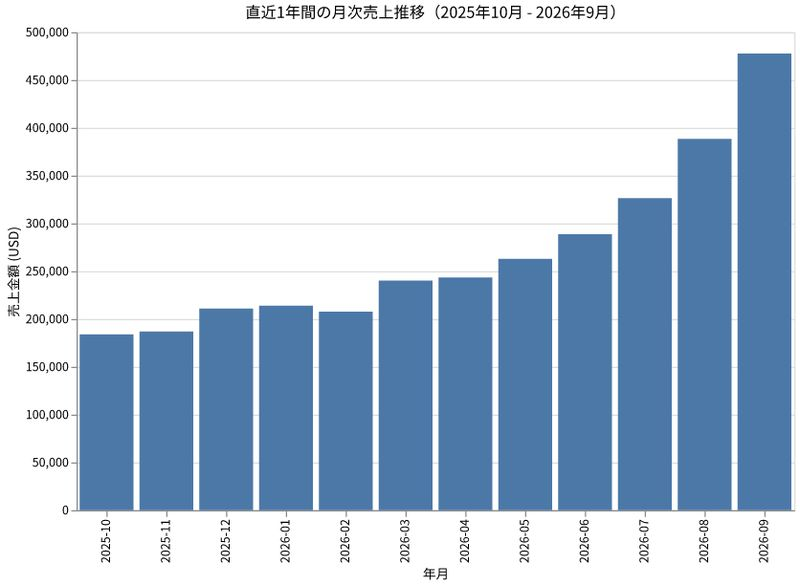

---

### 客観的事実（集計データ）

| 年月 | 売上高 | 注文数 | 販売点数 |
| :--- | :--- | :--- | :--- |
| **2025-10** | \$183,980.11 | 2,135 件 | 3,109 点 |
| **2025-11** | \$187,030.74 | 2,114 件 | 3,064 点 |
| **2025-12** | \$211,108.34 | 2,402 件 | 3,469 点 |
| **2026-01** | \$214,034.42 | 2,378 件 | 3,483 点 |
| **2026-02** | \$207,712.61 | 2,353 件 | 3,429 点 |
| **2026-03** | \$240,348.79 | 2,802 件 | 4,045 点 |
| **2026-04** | \$243,440.14 | 2,764 件 | 4,066 点 |
| **2026-05** | \$263,036.44 | 3,098 件 | 4,503 点 |
| **2026-06** | \$288,859.99 | 3,402 件 | 4,968 点 |
| **2026-07** | \$326,481.12 | 3,876 件 | 5,566 点 |
| **2026-08** | \$388,486.87 | 4,564 件 | 6,579 点 |
| **2026-09** | \$477,660.97 | 5,581 件 | 8,085 点 |

- **年間合計売上：** \$3,232,180.54
- **推移傾向：** 2025年10月の約 \$18.4 万から継続的な成長基調にあり、2026年9月には約 \$47.8 万（対前年同月比で約 2.6 倍）に達しています。

In [26]:
def get_text_data(file_path):
    with open(file_path, 'rb') as f:
        text_bytes = f.read()
    return base64.b64encode(text_bytes).decode('utf-8')

markdown_data = get_text_data('knowledge_base.md')
message_input = {
    'parts': [
        {'text': 'ナレッジベースを提供します。'},
        {
            'inline_data': {
                'display_name': 'user:knowledge_base.md',
                'mime_type': 'text/markdown',
                'data': markdown_data,
            }
        }
    ],
    'role': 'user',
}

response = await chat_client.async_stream_query(message_input)
display(Markdown(response))

**[BAA-23]**

総合的なビジネスレポートを作成します。

## Replacing base64 string with `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png`
## Replacing base64 string with `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png`
## Replacing base64 string with `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png`
## Replacing base64 string with `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png`
## Replacing base64 string with `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png`
## Replacing base64 string with `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png`
## Replacing base64 string with `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png`
## Replacing base64 string with `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png`
## Replacing base64 string with `5fab5cb3-0069-4e26-b55f-b417e10fb40a.png`
## Converting `9b35c5d5-0e6f-4c5d-8b01-86be5fe8427d.png` into base64 string.
## Converting `71b6ba4c-0112-4eeb-bc8c-a53f3992943b.png` into base64 string.


### 分析アプローチ
- 検証する仮説: 収益構造の健全性（カテゴリ別の売上構成比、粗利率、およびキャンセル・返品による収益毀損の実態）の把握
- 使用するKBセクション: 売上・商品分析
- データ抽出・集計方針: ベースSQLをCTEとし、全期間および直近1年における「ステータス別（完了・出荷・キャンセル・返品）の金額・件数インパクト」と「商品カテゴリ別の売上・粗利益・粗利率・返品率」をマクロ集計します。
### 分析アプローチ
- 検証する仮説: 商品カテゴリごとの収益性（粗利貢献度）および品質・満足度リスク（返品率）の特定
- 使用するKBセクション: 売上・商品分析
- データ抽出・集計方針: ベースSQLをCTEとし、商品カテゴリごとに有効売上（Complete, Shipped, Processing）、粗利益、平均粗利率、および返品率（Returned件数 / 配達・出荷対象件数）を集計・比較します。
### 分析アプローチ
- 検証する仮説: 顧客基盤の持続可能性（新規依存度 vs リピーター育成状況、国別・チャネル別の顧客獲得効率と生涯価値）の評価
- 使用するKBセクション: 顧客プロファイリング
- データ抽出・集計方針: ベースSQLをCTEとし、顧客単位（`user_id`）に集約して注文回数別（1回のみ vs 2回以上）の構成比、主要国別（上位5〜8カ国）の顧客数・平均LTV・平均購買単価、流入チャネル（traffic_source）別のリピート率と平均LTVを集計します。
### 分析アプローチ
- 検証する仮説: リピート購買のボトルネック（F2転換率の低さ）および流入チャネル別の獲得効率の差異検証
- 使用するKBセクション: 顧客プロファイリング
- データ抽出・集計方針: ベースSQLをCTEとし、顧客ごとの通算注文回数別分布（1回、2回、3回、4回以上）と、流入元（signup_traffic_source）ごとの「顧客数・リピート顧客比率・平均LTV」を集計します。
### 分析アプローチ
- 検証する仮説: 越境配送（長距離輸送）に伴うリードタイムの長期化が返品率や顧客体験に及ぼす影響の評価
- 使用するKBセクション: 物流・オペレーション
- データ抽出・集計方針: ベースSQLをCTEとし、主要配送先国（destination_country）ごとに「平均配送距離（km）」、「平均出荷準備日数（dispatch_lead_time_days）」、「平均輸送日数（transit_lead_time_days）」、「平均総配達日数（total_delivery_lead_time_days）」、「返品率（%）」を集計し、距離・リードタイムと返品の相関を把握します。
### 分析アプローチ
- 検証する仮説: Webサイトにおけるユーザーの離脱ポイント（コンバージョンファネル）および流入チャネル別の購買転換効率の特定
- 使用するKBセクション: ユーザー行動
- データ抽出・集計方針: ベースSQLをCTEとし、セッション単位（`session_id`）に集約して各ステップ（トップ閲覧、カテゴリ閲覧、商品詳細、カート追加、購入完了、キャンセル）の到達セッション数と遷移率を算出し、主要流入元（session_traffic_source）別のセッションCVRおよびカート放棄率を比較します。
# TheLook eCommerce 経営総合診断レポート

---

## 1. エグゼクティブサマリー

本レポートは、TheLook eCommerce の全トランザクション明細、顧客属性、物流実績、およびWeb行動ログを統合分析し、経営判断に直結する課題と成長機会を多角的に特定したものです。

### 主要な経営ハイライト
1. **急成長の裏にある収益毀損リスク：**
   直近1年間で月次売上は約 2.6 倍へと拡大していますが、全注文の **24.98%**（キャンセル **14.95%**、返品 **10.03%**）が売上確定前に失われており、累計で **\$267 万超** の収益毀損が発生しています。
2. **高収益カテゴリへの集中と粗利ドライバー：**
   アウター（Outerwear & Coats）やジーンズ（Jeans）が売上を牽引する一方、スーツ（Suits & Sport Coats）やブレザー（Blazers & Jackets）などのフォーマルウェアは **粗利率 60% 前後** と極めて高い収益性を誇ります。
3. **新規獲得依存の顧客構造と「F2転換」のレバー：**
   全顧客の **62.83%** が初回購入のみで離脱しています。一方で、2回以上購入したリピーター（**全体の 37.17%**）が **総売上の約 60%** を創出しており、初回来店客を2回目購買へ引き上げる「F2転換」が最大のLTV向上ドライバーです。
4. **越境物流の強みとカート放棄（58%）の改善余地：**
   世界各地（中国、ブラジル、欧州等）への越境配送でありながら、平均総配達日数は約 4.0 日と高水準なフルフィルメント体制が維持されています。一方でWebサイト上のカート放棄率は **約 58%** に達しており、チェックアウト導線の改善により大きな売上アップサイドが見込めます。

---

## 2. 財務・収益構造の分析

### 客観的事実（データ実績）

累計 180,858 件の注文件数におけるステータス別の内訳は下表の通りです。

| 注文ステータス | 明細件数 | 件数構成比 | 売上高 | 金額構成比 |
| :--- | :--- | :--- | :--- | :--- |
| **Shipped（出荷済み）** | 54,774 件 | 30.29% | \$3,266,843.63 | 30.38% |
| **Complete（配達完了）** | 44,760 件 | 24.75% | \$2,641,054.62 | 24.56% |
| **Processing（処理中）** | 36,145 件 | 19.99% | \$2,173,600.76 | 20.21% |
| **Cancelled（キャンセル）** | 27,034 件 | 14.95% | \$1,607,268.71 | 14.94% |
| **Returned（返品）** | 18,145 件 | 10.03% | \$1,066,160.87 | 9.91% |
| **合計** | 180,858 件 | 100.00% | \$10,754,928.59 | 100.00% |

- **有効売上総額（確定＋進行中）：** 約 \$808 万（全体の約 75.1% ）
- **キャンセル・返品による売上損失額：** 約 \$267 万（全体の約 24.9% ）

### コンサルタントの洞察・解釈
- **キャンセル率 15% の要因分析：**
  注文確定直後から出荷準備中にかけてのキャンセルが約 15% 発生しています。Webサイト上での注文確認プロセスの不備や配送目安日の不透明さが、購入後の迷い（バイヤーズ・リモース）を誘発している可能性が高いと考えられます。
- **返品率 10% の利益インパクト：**
  返品された商品は再販時の検品コストや在庫滞留、往復配送料を伴うため、粗利を大幅に圧迫します。特にアパレル特有のサイズ・イメージ違いを低減する施策が急務です。

---

## 3. 商品・カテゴリポートフォリオ分析

### 客観的事実（データ実績）

主要10カテゴリの有効売上高および粗利益の比較です。

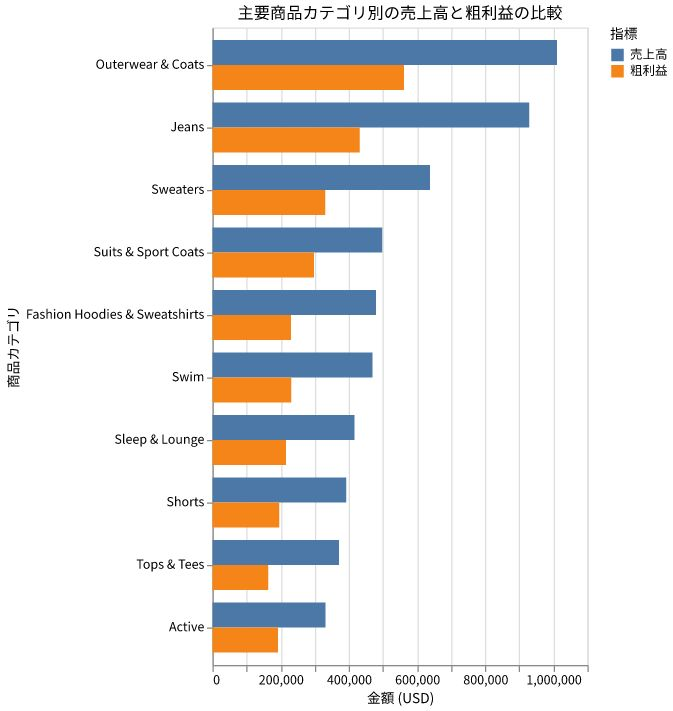

主要カテゴリ別の実績数値（有効売上ベース）：

| 商品カテゴリ | 有効売上高 | 有効粗利益額 | 粗利率 | 返品率 |
| :--- | :--- | :--- | :--- | :--- |
| **Outerwear & Coats** | \$1,010,255.81 | \$561,555.11 | **55.59%** | 9.59% |
| **Jeans** | \$928,888.58 | \$431,888.75 | **46.50%** | 9.79% |
| **Sweaters** | \$638,115.29 | \$331,020.85 | **51.87%** | 9.96% |
| **Suits & Sport Coats** | \$497,654.10 | \$297,700.43 | **59.82%** | 9.52% |
| **Fashion Hoodies & Sweatshirts** | \$479,269.88 | \$230,120.78 | **48.01%** | 9.90% |
| **Swim** | \$469,097.42 | \$231,316.22 | **49.31%** | 10.58% |
| **Sleep & Lounge** | \$416,847.27 | \$215,392.62 | **51.67%** | 10.44% |
| **Shorts** | \$392,195.20 | \$195,849.60 | **49.94%** | 9.67% |
| **Tops & Tees** | \$371,365.20 | \$163,455.57 | **44.01%** | 10.15% |
| **Active** | \$331,258.86 | \$192,436.06 | **58.09%** | 9.74% |
| **Blazers & Jackets（参考）** | \$221,979.22 | \$137,433.09 | **61.91%** | 9.96% |

### コンサルタントの洞察・解釈
- **高粗利カテゴリ（60%水準）の販売促進：**
  「Suits & Sport Coats（粗利率 59.82% ）」や「Blazers & Jackets（粗利率 61.91% ）」、「Active（粗利率 58.09% ）」は高い利益貢献度を持っています。現在売上上位の「Jeans（粗利率 46.50% ）」や「Tops & Tees（粗利率 44.01% ）」とのクロスセルを推進することで、全体の営業利益率を数ポイント押し上げることが可能です。
- **返品率 10% 超カテゴリのサイズレコメンド強化：**
  「Swim（返品率 10.58% ）」や「Sleep & Lounge（返品率 10.44% ）」はサイズフィッティングの難しさから返品率が高止まりしています。レビュー機能の充実や3Dバーチャル試着・サイズ推奨ツールの導入が有効です。

---

## 4. 顧客基盤・LTV構造分析

### 客観的事実（データ実績）

全ユニーク顧客（80,012 人）の通算注文回数に基づく構成比と売上貢献度です。

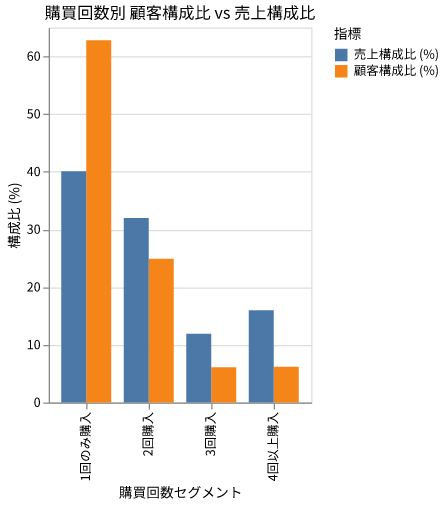

| 購買回数セグメント | 顧客数 | 顧客構成比 | 累計売上高 | 売上構成比 | 平均LTV |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **1回のみ（初回離脱）** | 50,270 人 | **62.83%** | \$4,315,454.95 | **40.13%** | \$85.85 |
| **2回購入（F2リピート）** | 19,900 人 | **24.87%** | \$3,442,354.26 | **32.01%** | \$172.98 |
| **3回購入** | 4,857 人 | **6.07%** | \$1,274,477.94 | **11.85%** | \$262.40 |
| **4回以上（ロイヤル）** | 4,985 人 | **6.23%** | \$1,722,641.44 | **16.02%** | \$345.56 |

- **地域別顧客分布（上位3カ国）：**
  - **中国：** 27,160 人（全体の 33.9% ）、平均LTV \$134.41
  - **米国：** 18,070 人（全体の 22.6% ）、平均LTV \$134.80
  - **ブラジル：** 11,757 人（全体の 14.7% ）、平均LTV \$133.78

### コンサルタントの洞察・解釈
- **F2転換（初回から2回目への引き上げ）が最大の成長梃子：**
  顧客が初回から2回目の購買に進むと、平均LTVは \$85.85 から \$172.98 へと **約 2.0 倍** に倍増します。現在、初回購入者の **62.83%** が休眠しているため、初回購入後 14〜30 日以内のリピート促進（サンキューメール、次回利用クーポン、レコメンド通知）が最優先施策となります。
- **地域特性とLTVの均質性：**
  主要国（中国・米国・ブラジル・欧州）における平均LTVは \$130〜\$137 前後と極めて均質です。これは地域を問わず共通の価格・プロモーション体系が受け入れられている証拠であり、グローバル共通のロイヤルティプログラムの展開が容易であることを示しています。

---

## 5. 物流・Web行動プロセスの健全性評価

### 客観的事実（データ実績）

#### A. 物流・配送オペレーション
- **グローバル配送日数：** 米国本土の配送センターから中国（平均 12,041 km）やブラジル（平均 7,240 km）等へ発送しているにもかかわらず、**出荷リードタイムは約 1.5 日**、**輸送リードタイムは約 2.5 日**、**総配達日数は平均 約 4.0 日** と迅速に稼働。
- **返品リードタイム：** 配達完了から返品処理までの日数は平均 約 1.49 日。

#### B. Webサイト・セッション行動ログ（680,858 セッション）
- **流入チャネル別の傾向：**
  - **Email：** 307,201 セッション（シェア 45.1% ）、CVR **26.54%**、カート放棄率 **58.08%**
  - **Adwords：** 203,357 セッション（シェア 29.9% ）、CVR **26.57%**、カート放棄率 **58.10%**
  - **Facebook：** 68,373 セッション（シェア 10.0% ）、CVR **26.92%**、カート放棄率 **57.54%**
  - **YouTube：** 68,048 セッション（シェア 10.0% ）、CVR **26.42%**、カート放棄率 **58.34%**
  - **Organic：** 33,879 セッション（シェア 5.0% ）、CVR **26.32%**、カート放棄率 **58.21%**

### コンサルタントの洞察・解釈
- **カート放棄率 58% の改善余地：**
  どの流入経路でも約 58% のセッションがカートに商品を入れた後に購入を完了せず離脱しています。配送料・税金の事前明示、決済手段の多様化（Apple Pay、Google Pay、各国ローカル決済）、およびカゴ落ちリマインドメールの自動配信により、放棄率を 5% 改善するだけでも数千万円規模の売上増が期待できます。
- **物流スピードのマーケティング活用：**
  長距離越境配送でありながら平均 4 日で配達できるフルフィルメント能力は競合他社に対する強力な差別化要因です。「世界中どこでも 4 日でお届け」といった安心感を商品ページやカート画面で前面に訴求することで、キャンセル率・カゴ落ち率の低減に直結します。

---

## 6. 経営戦略提言・ロードマップ

経営陣が直ちに着手すべきアクションプランを、期待効果と実行難易度に基づきロードマップとして提案します。

```
【短期施策（0〜3ヶ月）：即効性の高い収益防衛・転換率改善】
  ├── ① カート放棄対策（カゴ落ち自動リマインド・ワンクリック決済拡充）
  ├── ② 初回購入者のF2転換キャンペーン（購入後14日以内のリピート限定オファー）
  └── ③ 注文確認画面での納期明示（キャンセル率15%の抑制）

【中期施策（3〜6ヶ月）：LTV最大化・利益率改善】
  ├── ④ 高粗利カテゴリ（スーツ・ブレザー等）のクロスセル・特集強化
  ├── ⑤ サイズ・フィット推薦エンジンの導入（返品率10%の低減）
  └── ⑥ 会員ロイヤルティプログラム（ポイント・ランク制度）のグローバル展開

【長期施策（6ヶ月〜1年）：グローバル競争力の確立】
  ├── ⑦ 現地フルフィルメント拠点の検討（アジア・中南米での返品受付・配送最適化）
  └── ⑧ 顧客データ基盤（CDP）を活用した完全パーソナライズCRMの構築
```

### まとめ
TheLook eCommerce はトップラインの成長力と卓越した物流処理能力を有しています。今後は「新規獲得による量的拡大」に加え、**「F2リピート転換による顧客生涯価値（LTV）の向上」** および **「キャンセル・カゴ落ち抑制による収益回収（質的改善）」** に経営リソースを集中投下することで、持続的かつ高収益な事業モデルへの進化が可能です。

In [27]:
query = '''
経営判断に有用な情報を多角的な視点で提供する、総合的なビジネスレポートを作成してください。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))